# BrightFocus 2P ROI + processed rotary mean velocity plots

This notebook is a clean version that keeps TIFF/ROI extraction separate from behavior alignment.

It does four things:

1. Loads the 2P TIFF and ImageJ ROI zip.
2. Visualizes ROIs on the max projection.
3. Extracts ROI traces, computes dF/F, individual traces, and z-scored heatmap.
4. Loads the **processed rotary CSV** and aligns **mean velocity per imaging frame** to the calcium data.

The rotary file is assumed to already contain `vel_linear_spline`.


In [2]:
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt

from pathlib import Path
from roifile import roiread
from matplotlib.path import Path as MplPath
from matplotlib.patches import Polygon
from scipy.ndimage import percentile_filter


## 1. Paths and settings

In [17]:
# ----------------------------
# File paths
# ----------------------------
tif_path = "/Volumes/rkc_ramirezlab/Home/suthardr/Projects/3p_hadas/H19_processed/timeseries/TS_noBkg_E_10_Iter_9909_output-1.tif"
roi_path = "/Volumes/rkc_ramirezlab/Home/suthardr/Projects/3p_hadas/H19_processed/timeseries/RoiSet_9909.zip"

# Uploaded processed rotary CSV
processed_rotary_path = "/Volumes/rkc_ramirezlab/Home/suthardr/Projects/3p_hadas/H19_processed/03312026_rotary_H19/processed/processedRotary_rotary_H19_small_FOV_940um_6_4hz.csv"

# ----------------------------
# Acquisition settings
# ----------------------------
fs = 6.736  # imaging Hz

# Plotting window
end_frame = 1500  # use None for full movie

# dF/F settings
baseline_percentile = 20
baseline_win_s = 20
smooth_k = 3

# Plot aesthetics
plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 2. Helper functions

In [4]:
def load_rois(roi_path):
    """Load ImageJ ROIs from .roi or .zip."""
    rois = roiread(roi_path)
    if not isinstance(rois, (list, tuple)):
        rois = [rois]
    return rois


def orient_stack_safely(stack_raw):
    """
    Return stack as (T, H, W).

    This is intentionally conservative to avoid axis-guessing artifacts.

    For this dataset, if the raw TIFF shape is exactly (320, 1500, 320),
    it is treated as (H, T, W) and converted to (T, H, W).

    Otherwise, the TIFF is assumed to already be (T, H, W).
    """
    stack_raw = np.asarray(stack_raw)

    if stack_raw.ndim != 3:
        raise ValueError(f"Expected 3D TIFF stack, got shape {stack_raw.shape}")

    if stack_raw.shape == (320, 1500, 320):
        stack = np.moveaxis(stack_raw, 1, 0)
        print("Detected raw TIFF shape (H,T,W); moved axis 1 to front.")
    else:
        stack = stack_raw
        print("Using raw TIFF as already (T,H,W).")

    return stack


def rois_to_masks(roi_path, image_shape):
    """
    Convert ImageJ polygon ROIs to masks.

    Parameters
    ----------
    roi_path : str
        Path to ImageJ ROI zip.
    image_shape : tuple
        (H, W)

    Returns
    -------
    masks : array
        Boolean masks, shape (N, H, W)
    coords_list : list
        ROI polygon coordinate arrays.
    """
    H, W = image_shape
    rois = load_rois(roi_path)

    yy, xx = np.mgrid[0:H, 0:W]
    pts = np.column_stack((xx.ravel(), yy.ravel()))

    masks = []
    coords_list = []

    for r in rois:
        xy = r.coordinates()
        if xy is None or len(xy) == 0:
            continue

        m = MplPath(xy).contains_points(pts).reshape(H, W)
        masks.append(m)
        coords_list.append(xy)

    masks = np.stack(masks)

    return masks, coords_list


def extract_traces(stack, masks):
    """
    Extract mean fluorescence trace for each ROI.

    stack: (T, H, W)
    masks: (N, H, W)
    returns F: (T, N)
    """
    T, H, W = stack.shape
    flat = stack.reshape(T, H * W)

    F = np.empty((T, masks.shape[0]), dtype=float)

    for i in range(masks.shape[0]):
        idx = np.flatnonzero(masks[i].ravel())
        F[:, i] = flat[:, idx].mean(axis=1)

    return F


def smooth_for_plot(x, k=3):
    """Moving-average smoothing along time axis. For visualization only."""
    if k is None or k <= 1:
        return x.copy()

    kernel = np.ones(k) / k

    if x.ndim == 1:
        return np.convolve(x, kernel, mode="same")

    y = np.empty_like(x, dtype=float)
    for i in range(x.shape[1]):
        y[:, i] = np.convolve(x[:, i], kernel, mode="same")

    return y


def dff_rolling_percentile(F, fs, win_s=20, p=20):
    """
    Rolling percentile baseline dF/F.

    F: (T, N)
    """
    win = int(round(win_s * fs))
    win = max(win, 3)
    if win % 2 == 0:
        win += 1

    F0 = np.empty_like(F, dtype=float)

    for i in range(F.shape[1]):
        F0[:, i] = percentile_filter(
            F[:, i],
            percentile=p,
            size=win,
            mode="nearest"
        )

    dff = (F - F0) / np.clip(F0, 1e-9, None)
    return dff


def zscore_traces(x):
    """Z-score each ROI trace independently."""
    return (x - np.nanmean(x, axis=0)) / (np.nanstd(x, axis=0) + 1e-9)


## 3. Load TIFF, ROIs, and extract traces

In [5]:
stack_raw = tifffile.imread(tif_path)
print("Raw TIFF shape:", stack_raw.shape)

stack = orient_stack_safely(stack_raw)
T, H, W = stack.shape
print("Stack used for extraction:", stack.shape)

masks, coords_list = rois_to_masks(roi_path, image_shape=(H, W))
print("Masks shape:", masks.shape)

F = extract_traces(stack, masks)
print("F shape:", F.shape)
print("Raw F range:", np.nanmin(F), np.nanmax(F))


Raw TIFF shape: (1500, 320, 320)
Using raw TIFF as already (T,H,W).
Stack used for extraction: (1500, 320, 320)
Masks shape: (65, 320, 320)
F shape: (1500, 65)
Raw F range: 5026.83349609375 7631.75


## 4. Sanity check extraction

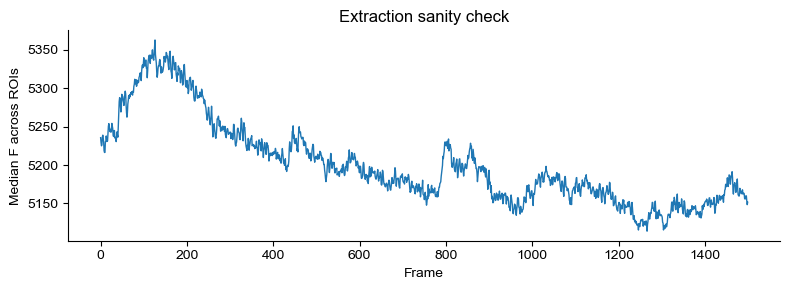

Frames with median F < 1% of median: []


In [6]:
global_F = np.nanmedian(F, axis=1)

plt.figure(figsize=(8, 3))
plt.plot(global_F, lw=1)
plt.xlabel("Frame")
plt.ylabel("Median F across ROIs")
plt.title("Extraction sanity check")
plt.tight_layout()
plt.show()

near_zero_frames = np.where(global_F < 0.01 * np.nanmedian(global_F))[0]
print("Frames with median F < 1% of median:", near_zero_frames)


## 5. ROI outlines on max projection

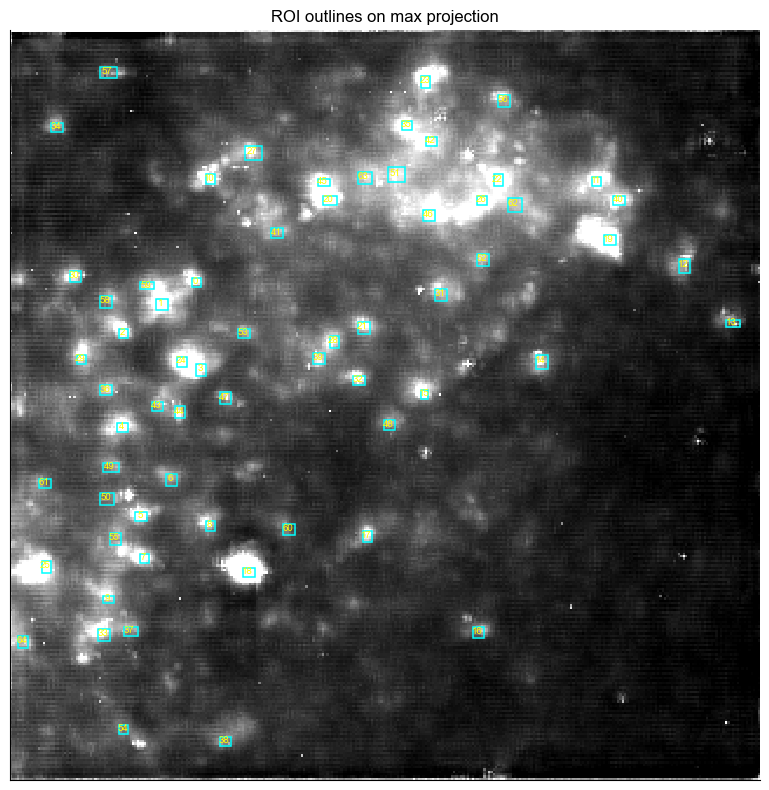

In [7]:
max_img = np.nanmax(stack, axis=0)

vmin = np.nanpercentile(max_img, 2)
vmax = np.nanpercentile(max_img, 98)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(max_img, cmap="gray", vmin=vmin, vmax=vmax, interpolation="nearest")

for i, xy in enumerate(coords_list):
    patch = Polygon(
        xy,
        closed=True,
        fill=False,
        edgecolor="cyan",
        linewidth=1.1
    )
    ax.add_patch(patch)

    cx = np.mean(xy[:, 0])
    cy = np.mean(xy[:, 1])
    ax.text(cx, cy, str(i), color="yellow", fontsize=7, ha="center", va="center")

ax.set_title("ROI outlines on max projection")
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()


## 6. Compute dF/F and z-score

In [18]:
dff = dff_rolling_percentile(
    F,
    fs=fs,
    win_s=baseline_win_s,
    p=baseline_percentile
)

dff_plot = smooth_for_plot(dff, k=smooth_k)
z = zscore_traces(dff_plot)

# Sort heatmap by activity
activity = np.nanstd(z, axis=0)
order = np.argsort(-activity)
z_sorted = z[:, order]

print("dff shape:", dff.shape)
print("z shape:", z.shape)


dff shape: (1500, 65)
z shape: (1500, 65)


## 7. Load processed rotary file and compute mean velocity per imaging frame

In [19]:
rot = pd.read_csv(processed_rotary_path)

print("Rotary columns:")
print(rot.columns.tolist())
print(rot.head())

required = {"time_s", "vel_linear_spline"}
missing = required - set(rot.columns)
if missing:
    raise ValueError(f"Processed rotary file is missing columns: {sorted(missing)}")

# Raw processed rotary timestamps and velocity
t_rot = rot["time_s"].to_numpy(dtype=float)
v_rot = rot["vel_linear_spline"].to_numpy(dtype=float)

# Align behavior start to imaging start.
# Comment this out if the time_s column is already aligned to imaging time zero.
t_rot = t_rot - t_rot[0]

# Choose signed velocity or absolute speed.
# For mean velocity with direction, keep signed:
v_for_alignment = v_rot

# For movement magnitude instead, use:
# v_for_alignment = np.abs(v_rot)

# Imaging frame bins
T = F.shape[0]
frame_edges = np.arange(T + 1) / fs

# Assign rotary samples to imaging frame bins
frame_idx = np.digitize(t_rot, frame_edges) - 1

valid = (frame_idx >= 0) & (frame_idx < T) & np.isfinite(v_for_alignment)
frame_idx_valid = frame_idx[valid]
v_valid = v_for_alignment[valid]

mean_velocity = np.full(T, np.nan, dtype=float)

# Mean velocity within each imaging-frame time bin
for i in range(T):
    vals = v_valid[frame_idx_valid == i]
    if len(vals) > 0:
        mean_velocity[i] = np.nanmean(vals)

# Fill any empty imaging frames by interpolation
x = np.arange(T)
good = np.isfinite(mean_velocity)

if good.sum() < 2:
    raise ValueError("Not enough valid rotary samples to align to imaging.")

mean_velocity = np.interp(x, x[good], mean_velocity[good])

t_img = np.arange(T) / fs

print("mean_velocity shape:", mean_velocity.shape)
print("mean_velocity range:", np.nanmin(mean_velocity), np.nanmax(mean_velocity))


Rotary columns:
['time_s', 'position_deg', 'theta_deg_unwrapped0', 'theta_deg_spline', 'vel_deg_s_spline', 'acc_deg_s2_spline', 'vel_linear_spline', 'acc_linear_spline', 'cum_dist_linear_spline']
     time_s  position_deg  theta_deg_unwrapped0  theta_deg_spline  \
0  0.093887          92.6                   0.0         -0.166500   
1  0.292387          92.5                  -0.1          0.017544   
2  0.415587          92.6                   0.0          0.061180   
3  0.666687          92.5                  -0.1          0.007035   
4  0.798187          92.6                   0.0         -0.086417   

   vel_deg_s_spline  acc_deg_s2_spline  vel_linear_spline  acc_linear_spline  \
0          1.309578          -4.032268           0.205708          -0.633387   
1          0.562574          -3.494220           0.088369          -0.548871   
2          0.152657          -3.160277           0.023979          -0.496415   
3         -0.555436          -2.479652          -0.087248          -0

## 8. Check aligned mean velocity

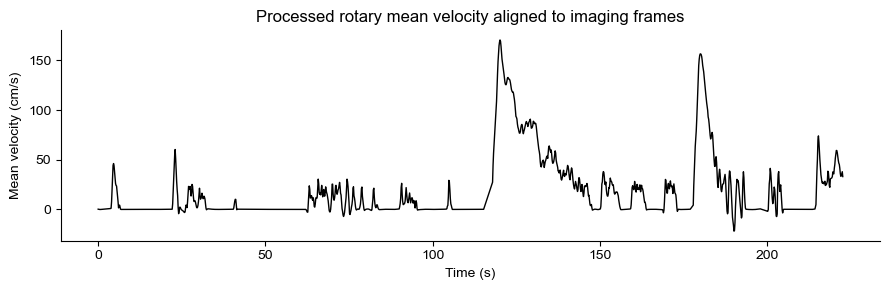

In [20]:
end = F.shape[0] if end_frame is None else min(end_frame, F.shape[0])

plt.figure(figsize=(9, 3))
plt.plot(t_img[:end], mean_velocity[:end], color="black", lw=1)
plt.xlabel("Time (s)")
plt.ylabel("Mean velocity (cm/s)")
plt.title("Processed rotary mean velocity aligned to imaging frames")
plt.tight_layout()
plt.show()


## 9. Individual ROI traces

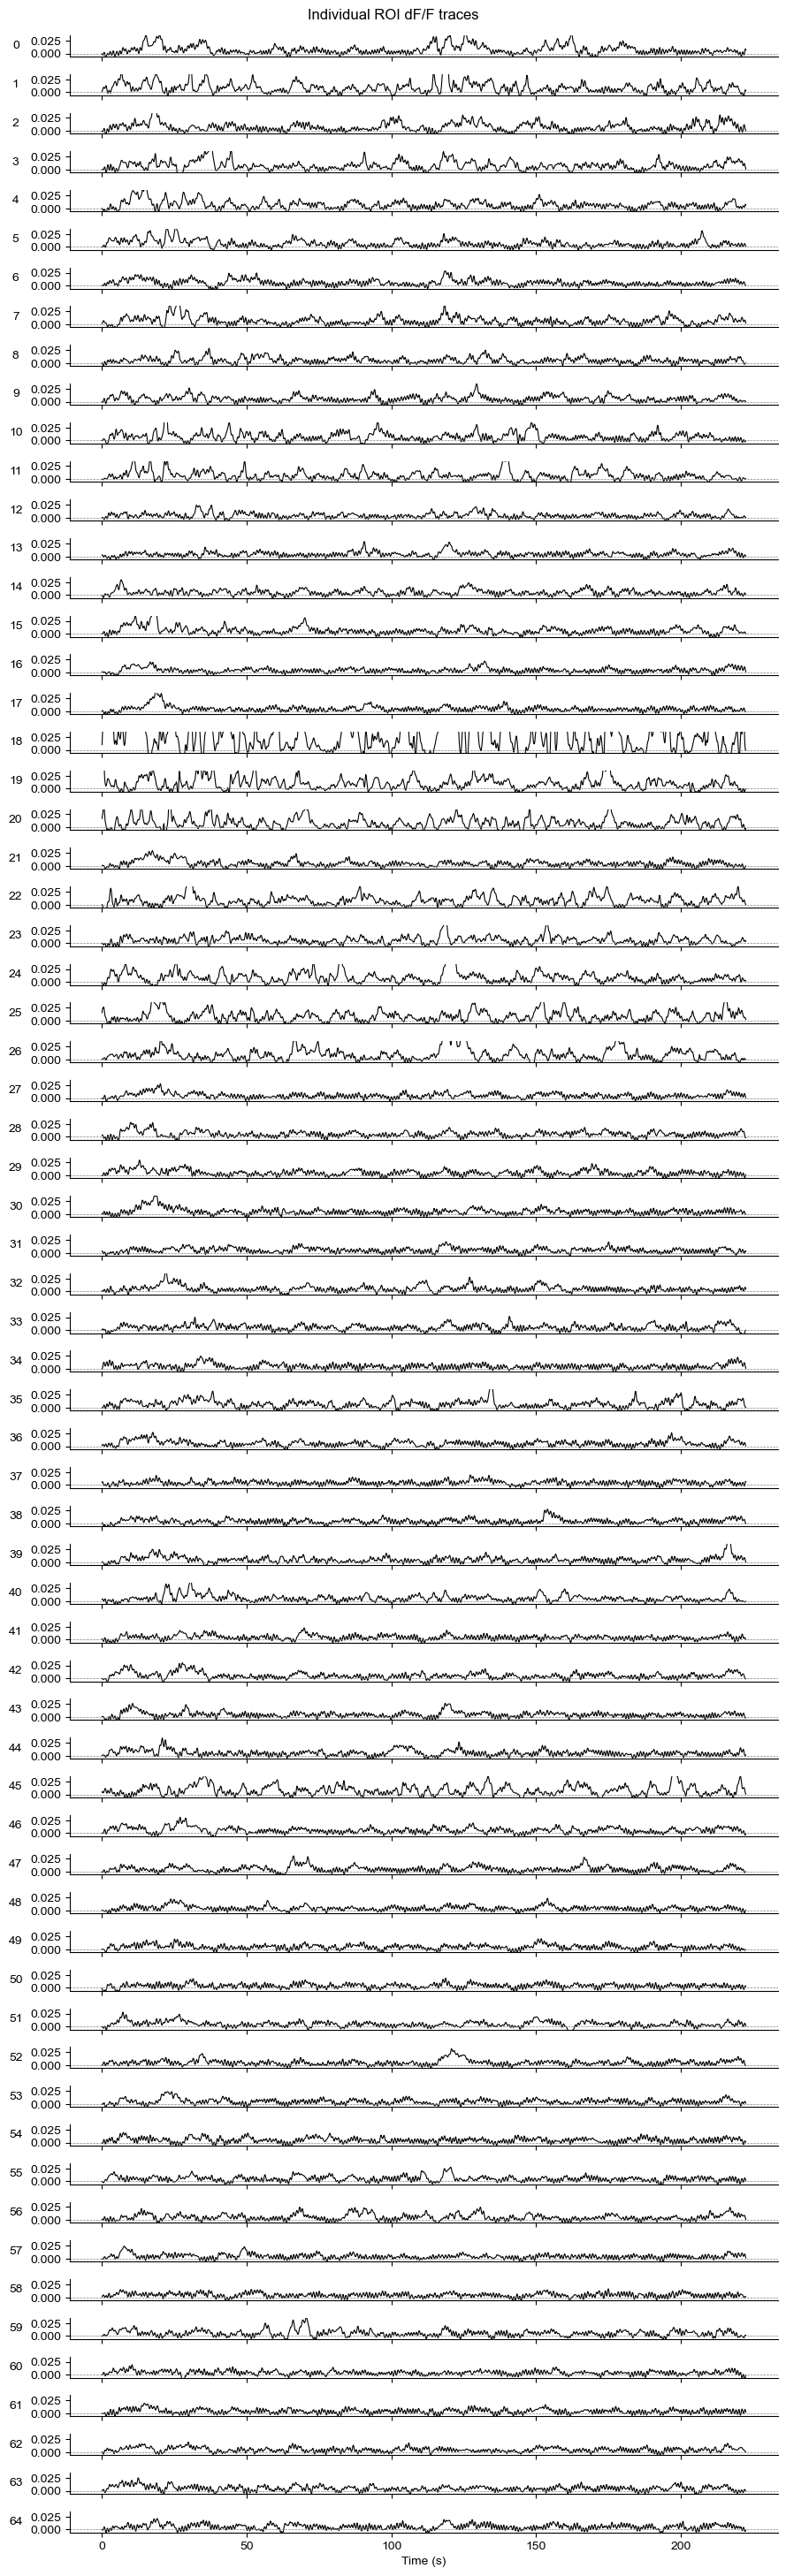

In [21]:
end = F.shape[0] if end_frame is None else min(end_frame, F.shape[0])
t = t_img

roi_indices = np.arange(dff_plot.shape[1])

fig, axes = plt.subplots(
    len(roi_indices),
    1,
    figsize=(9, max(6, 0.45 * len(roi_indices))),
    sharex=True
)

if len(roi_indices) == 1:
    axes = [axes]

ymin = np.nanpercentile(dff_plot[:end, roi_indices], 1)
ymax = np.nanpercentile(dff_plot[:end, roi_indices], 99)

for ax, roi_idx in zip(axes, roi_indices):
    ax.plot(t[:end], dff_plot[:end, roi_idx], color="black", lw=0.8)
    ax.axhline(0, color="gray", linestyle="--", lw=0.5)
    ax.set_ylabel(f"{roi_idx}", rotation=0, labelpad=12, va="center")
    ax.set_ylim(ymin, ymax)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Individual ROI dF/F traces", y=0.995)
plt.tight_layout()
plt.show()


## 10. Cute combined plot: traces, z-score heatmap, and mean velocity

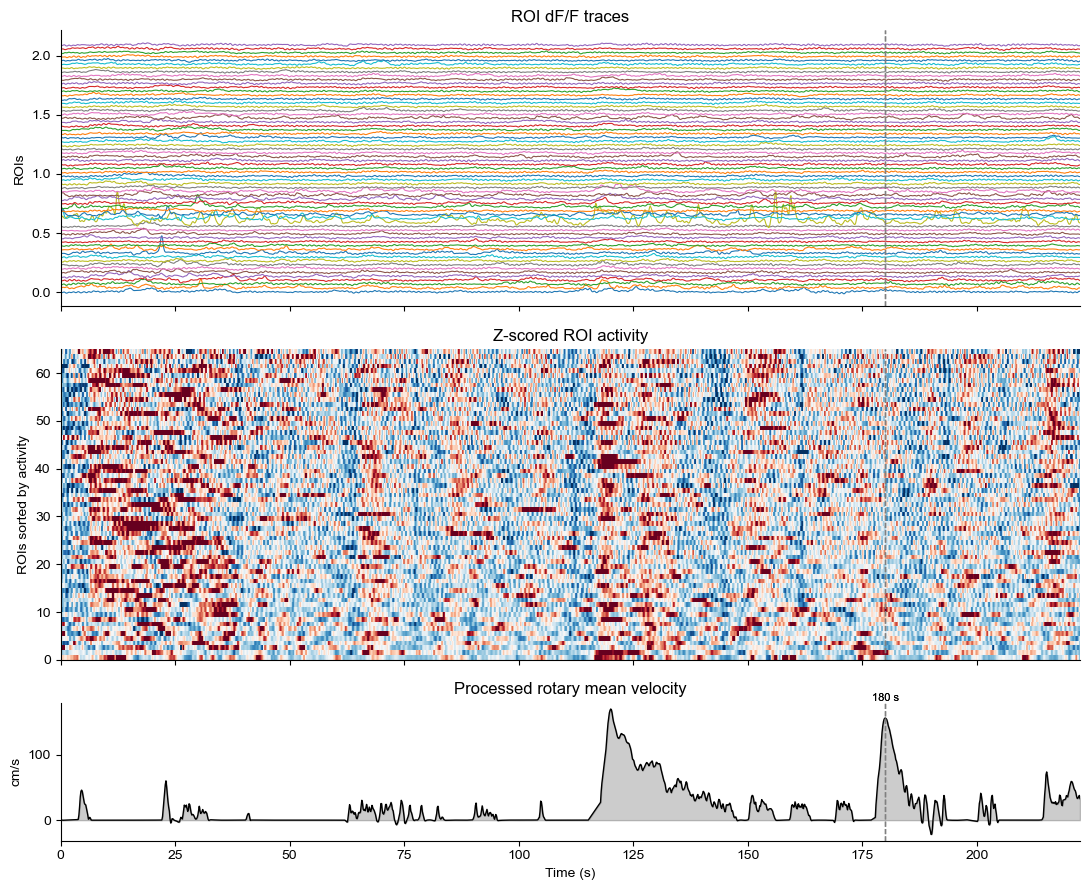

In [22]:
end = F.shape[0] if end_frame is None else min(end_frame, F.shape[0])

fig, axes = plt.subplots(
    3, 1,
    figsize=(11, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [1.6, 1.8, 0.8]}
)

# ----------------------------
# 1. Offset dF/F traces
# ----------------------------
spacing = (
    np.nanpercentile(dff_plot[:end], 99)
    - np.nanpercentile(dff_plot[:end], 1)
)
spacing = spacing * 0.8 if spacing > 0 else 0.2

for j in range(dff_plot.shape[1]):
    axes[0].plot(
        t[:end],
        dff_plot[:end, j] + j * spacing,
        lw=0.8
    )

axes[0].set_title("ROI dF/F traces")
axes[0].set_ylabel("ROIs")

# ----------------------------
# 2. Z-scored heatmap — use pcolormesh for exact time alignment
# ----------------------------

# Build pixel-edge bins: one extra edge beyond the last frame
dt = t[1] - t[0]  # assumes uniform sampling
t_edges = np.append(t[:end], t[end - 1] + dt)
roi_edges = np.arange(z_sorted.shape[1] + 1)

im = axes[1].pcolormesh(
    t_edges,
    roi_edges,
    z_sorted[:end].T,
    cmap="RdBu_r",
    vmin=-2,
    vmax=2,
    rasterized=True,   # keeps PDF/SVG exports fast
)

axes[1].set_title("Z-scored ROI activity")
axes[1].set_ylabel("ROIs sorted by activity")
# cbar = plt.colorbar(im, ax=axes[1], label="z-score", fraction=0.03, pad=0.01)

# ----------------------------
# 3. Mean velocity
# ----------------------------
axes[2].plot(
    t[:end],
    mean_velocity[:end],
    color="black",
    lw=1.0
)
axes[2].fill_between(
    t[:end],
    0,
    mean_velocity[:end],
    color="black",
    alpha=0.2
)

axes[2].set_title("Processed rotary mean velocity")
axes[2].set_ylabel("cm/s")
axes[2].set_xlabel("Time (s)")

# ----------------------------
# Enforce identical x-limits on all axes
# ----------------------------
x_lo, x_hi = t[0], t[end - 1]
for ax in axes:
    ax.set_xlim(x_lo, x_hi)

# After all drawing calls, before tight_layout:

# 1. Kill pcolormesh's automatic padding on the heatmap
axes[1].margins(x=0)

# 2. Enforce identical x-limits on ALL axes explicitly
x_lo, x_hi = t[0], t[end - 1]
for ax in axes:
    ax.set_xlim(x_lo, x_hi)

plt.tight_layout()

# 3. Reference lines — after tight_layout so ylim is stable
for event_s, label in [(180, "180 s"), (240, "240 s")]:
    if x_lo <= event_s <= x_hi:
        for ax in axes:
            ax.axvline(event_s, color="gray", linestyle="--", lw=1)
        axes[2].text(
            event_s,
            axes[2].get_ylim()[1],
            label,
            ha="center",
            va="bottom",
            fontsize=8
        )

# ----------------------------
# Reference lines (after tight_layout so ylim is stable)
# ----------------------------
for event_s, label in [(180, "180 s"), (240, "240 s")]:
    if x_lo <= event_s <= x_hi:
        for ax in axes:
            ax.axvline(event_s, color="gray", linestyle="--", lw=1)
        axes[2].text(
            event_s,
            axes[2].get_ylim()[1],
            label,
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.show()

## 11. Correlate each ROI with mean velocity

In [23]:
roi_velocity_corr = np.array([
    np.corrcoef(dff_plot[:, i], mean_velocity)[0, 1]
    for i in range(dff_plot.shape[1])
])

rank = np.argsort(-np.abs(roi_velocity_corr))

print("Top 10 ROIs correlated with mean velocity:")
for roi_idx in rank[:10]:
    print(f"ROI {roi_idx}: r = {roi_velocity_corr[roi_idx]:.3f}")


Top 10 ROIs correlated with mean velocity:
ROI 52: r = 0.452
ROI 26: r = 0.441
ROI 24: r = 0.328
ROI 0: r = 0.323
ROI 13: r = 0.233
ROI 2: r = 0.216
ROI 31: r = 0.215
ROI 43: r = 0.214
ROI 64: r = 0.202
ROI 1: r = 0.171


In [24]:
# Install if needed
try:
    import rastermap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "rastermap"])

import numpy as np
import matplotlib.pyplot as plt
from rastermap import Rastermap

# ----------------------------
# 1. Fit Rastermap on z-scored activity
#    Input shape: (n_neurons, n_timepoints)
# ----------------------------
model = Rastermap(
    n_clusters=50,        # number of clusters (superneurons)
    n_PCs=64,             # PCs to use for embedding
    locality=0.15,        # 0 = pure similarity, 1 = pure locality; 0.1–0.2 works well
    time_lag_window=10,   # captures temporal correlations across this many frames
    grid_upsample=10,     # upsampling for smoother sorting
)

# Rastermap expects (n_neurons, n_timepoints)
spks_input = z_scored.T    # your z_scored is (n_timepoints, n_neurons), so transpose

model.fit(spks_input)

isort = model.isort        # neuron ordering from Rastermap (length n_neurons)
embedding = model.embedding  # 1D embedding coordinate per neuron

# ----------------------------
# 2. Apply sorting to both z-scored and dF/F
# ----------------------------
z_raster   = z_scored[:, isort]    # (n_timepoints, n_neurons) sorted
dff_raster = dff_plot[:, isort]    # (n_timepoints, n_neurons) sorted

# ----------------------------
# 3. Plot — same 3-panel layout as before
# ----------------------------
end = F.shape[0] if end_frame is None else min(end_frame, F.shape[0])

fig, axes = plt.subplots(
    3, 1,
    figsize=(11, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [1.6, 1.8, 0.8]}
)

# --- Panel 1: dF/F traces, Rastermap-sorted ---
spacing = (
    np.nanpercentile(dff_raster[:end], 99)
    - np.nanpercentile(dff_raster[:end], 1)
)
spacing = spacing * 0.8 if spacing > 0 else 0.2

for j in range(dff_raster.shape[1]):
    axes[0].plot(t[:end], dff_raster[:end, j] + j * spacing, lw=0.5)

axes[0].set_title("ROI dF/F traces (Rastermap order)")
axes[0].set_ylabel("ROIs")

# --- Panel 2: Z-scored heatmap, Rastermap-sorted ---
dt = t[1] - t[0]
t_edges   = np.append(t[:end], t[end - 1] + dt)
roi_edges = np.arange(z_raster.shape[1] + 1)

im = axes[1].pcolormesh(
    t_edges,
    roi_edges,
    z_raster[:end].T,
    cmap="RdBu_r",
    vmin=-2,
    vmax=2,
    rasterized=True,
)

axes[1].set_title("Z-scored ROI activity (Rastermap order)")
axes[1].set_ylabel("ROIs")
cbar = plt.colorbar(im, ax=axes[1], label="z-score", fraction=0.03, pad=0.01)

# --- Panel 3: Mean velocity (unchanged) ---
axes[2].plot(t[:end], mean_velocity[:end], color="black", lw=1.0)
axes[2].fill_between(t[:end], 0, mean_velocity[:end], color="black", alpha=0.2)
axes[2].set_title("Processed rotary mean velocity")
axes[2].set_ylabel("cm/s")
axes[2].set_xlabel("Time (s)")

# --- Align all axes ---
axes[1].margins(x=0)
x_lo, x_hi = t[0], t[end - 1]
for ax in axes:
    ax.set_xlim(x_lo, x_hi)

plt.tight_layout()

# --- Reference lines ---
for event_s, label in [(180, "180 s"), (240, "240 s")]:
    if x_lo <= event_s <= x_hi:
        for ax in axes:
            ax.axvline(event_s, color="gray", linestyle="--", lw=1)
        axes[2].text(
            event_s, axes[2].get_ylim()[1], label,
            ha="center", va="bottom", fontsize=8
        )

plt.show()

  Using cached rastermap-1.0-py3-none-any.whl.metadata (20 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 12.9 MB/s  0:00:00 eta 0:00:01
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached natsort-8.4.0-py3-none-any.whl.metadata (21 kB)
  Using cached llvmlite-0.47.0.tar.gz (193 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): f

  error: subprocess-exited-with-error
  
  × Building wheel for llvmlite (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [63 lines of output]
      /private/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/pip-build-env-jc73ui_u/overlay/lib/python3.10/site-packages/setuptools/_vendor/wheel/bdist_wheel.py:4: FutureWarning: The 'wheel' package is no longer the canonical location of the 'bdist_wheel' command, and will be removed in a future release. Please update to setuptools v70.1 or later which contains an integrated version of this command.
        warn(
      running bdist_wheel
      Traceback (most recent call last):
        File "/private/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/pip-install-t5yxicr3/llvmlite_5f2e2f066dc84db9ab588bd180e25b7f/ffi/build.py", line 86, in check_cmake
          subprocess.run(("cmake", ), check=True, stdout=subprocess.PIPE,
        File "/Users/suthardr/opt/anaconda3/envs/dca1_rescue/lib/python3.10/subprocess.py", line 503, in ru

CalledProcessError: Command '['/Users/suthardr/opt/anaconda3/envs/dca1_rescue/bin/python', '-m', 'pip', 'install', 'rastermap']' returned non-zero exit status 1.